# 1. Imports and Setup ( Random Forest Classifier Model Training )

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

# Set aesthetics for plots
plt.style.use('ggplot')
sns.set_palette("muted")
%matplotlib inline

print("Libraries imported successfully!")


Libraries imported successfully!


### 2. Load and Inspect the Cleaned Data

Loading dataset from ../data/processed/cicids2017_cleaned.csv...
Dataset Shape: (2520751, 53)

Label Distribution:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


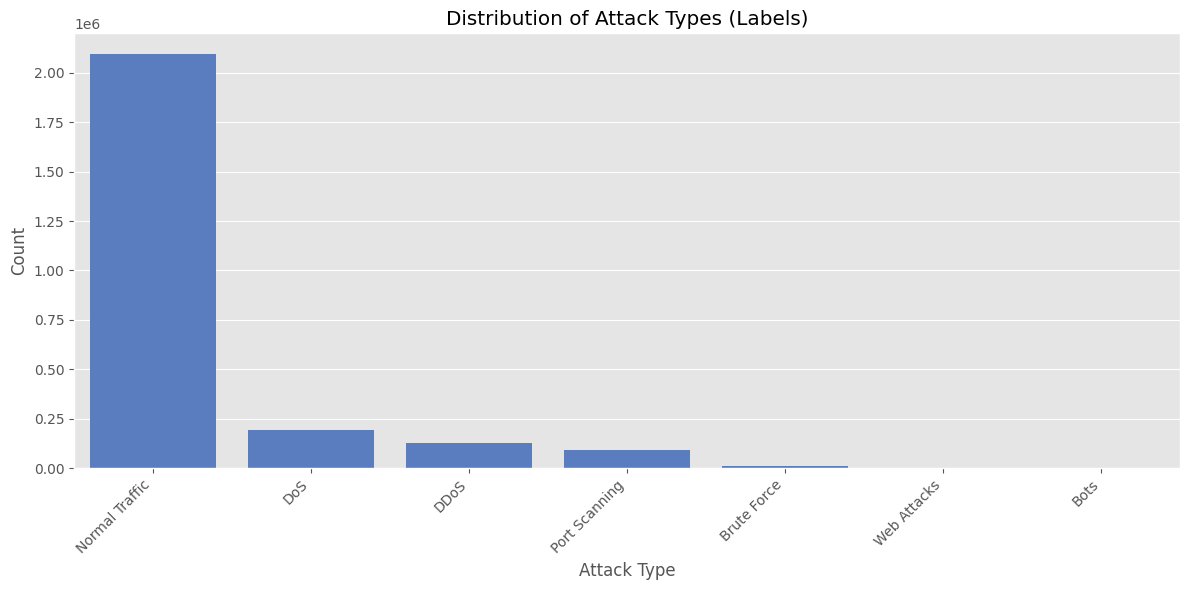

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [3]:
# Define the path to your newly uploaded dataset
data_path = '../data/processed/cicids2017_cleaned.csv'

print(f"Loading dataset from {data_path}...")
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}\n")

# Check the distribution of the target variable
if 'Attack Type' in df.columns:
    print("Label Distribution:")
    label_counts = df['Attack Type'].value_counts()
    print(label_counts)
    
    # Plot the distribution
    plt.figure(figsize=(12, 6))
    sns.barplot(x=label_counts.index, y=label_counts.values)
    plt.title('Distribution of Attack Types (Labels)')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("'Label' column not found! Here are the available columns:")
    print(df.columns.tolist())

# This will automatically display a nicely formatted table in Jupyter if it's the last line
df.head()

### 3. Feature Selection & Label Preparation

In [4]:
print("Original shape:", df.shape)

# Drop features that explicitly cause overfitting to the lab environment
features_to_drop = [
    'Destination Port', 
    'Fwd Header Length', 
    'Bwd Header Length', 
    'Init_Win_bytes_forward', 
    'Init_Win_bytes_backward', 
    'min_seg_size_forward'
]

# Keep only the robust 46 statistical features
cols_to_drop = [col for col in features_to_drop if col in df.columns]
df_clean = df.drop(columns=cols_to_drop)

print(f"Shape after dropping overfitting features: {df_clean.shape}")

# Separate Features (X) and Target (y)
y_raw = df_clean['Attack Type']
X = df_clean.drop(columns=['Attack Type'])

print("\nUnique Attack Types:")
print(y_raw.value_counts())

Original shape: (2520751, 53)
Shape after dropping overfitting features: (2520751, 47)

Unique Attack Types:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


### 4. Label Encoding and Train/Test Split

In [5]:
from sklearn.preprocessing import LabelEncoder

# 1. Encode text labels into numbers
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Label Mapping:")
for class_name, class_num in zip(le.classes_, le.transform(le.classes_)):
    print(f" {class_num} -> {class_name}")

# Create models directory if it doesn't exist
os.makedirs('../src/models', exist_ok=True)

# Save the encoder for the live app
joblib.dump(le, '../src/models/label_encoder.pkl')

# Save the feature names for the live app
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../src/models/layer2_features.pkl')
print(f"\nSaved {len(feature_names)} feature names for the live app.")

# 2. Train/Test Split
print("\nSplitting data (80% Train, 20% Test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


Label Mapping:
 0 -> Bots
 1 -> Brute Force
 2 -> DDoS
 3 -> DoS
 4 -> Normal Traffic
 5 -> Port Scanning
 6 -> Web Attacks

Saved 46 feature names for the live app.

Splitting data (80% Train, 20% Test)...
Training set size: (2016600, 46)
Testing set size: (504151, 46)


### 5. Train Random Forest Model

In [6]:
from sklearn.ensemble import RandomForestClassifier

custom_weights = {
    0: 10.0,   # Boost Bots
    1: 2.0,    
    2: 1.0,    
    3: 1.0,    
    4: 1.0,    
    5: 1.0,    
    6: 1.0     # Web Attacks
}

print("Training Robust Random Forest on 46 statistical features...")

# Robust RF: 100 trees, depth 20. Highly resistant to overfitting and new network traffic.
clf = RandomForestClassifier(
    n_estimators=100,      
    max_depth=20,          
    class_weight=custom_weights,
    random_state=42,
    n_jobs=-1              
)

clf.fit(X_train, y_train)
print("Training complete!")

joblib.dump(clf, '../src/models/layer2_model.pkl')
print("Model saved!")


Training Robust Random Forest on 46 statistical features...
Training complete!
Model saved!


### 6. Evaluation

Predicting on the 20% Test Set...

--- Classification Report ---
                precision    recall  f1-score   support

          Bots       0.61      0.58      0.59       389
   Brute Force       1.00      0.97      0.99      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       1.00      0.99      0.99     38749
Normal Traffic       1.00      1.00      1.00    419012
 Port Scanning       0.99      1.00      0.99     18139
   Web Attacks       1.00      0.93      0.96       429

      accuracy                           1.00    504151
     macro avg       0.94      0.92      0.93    504151
  weighted avg       1.00      1.00      1.00    504151



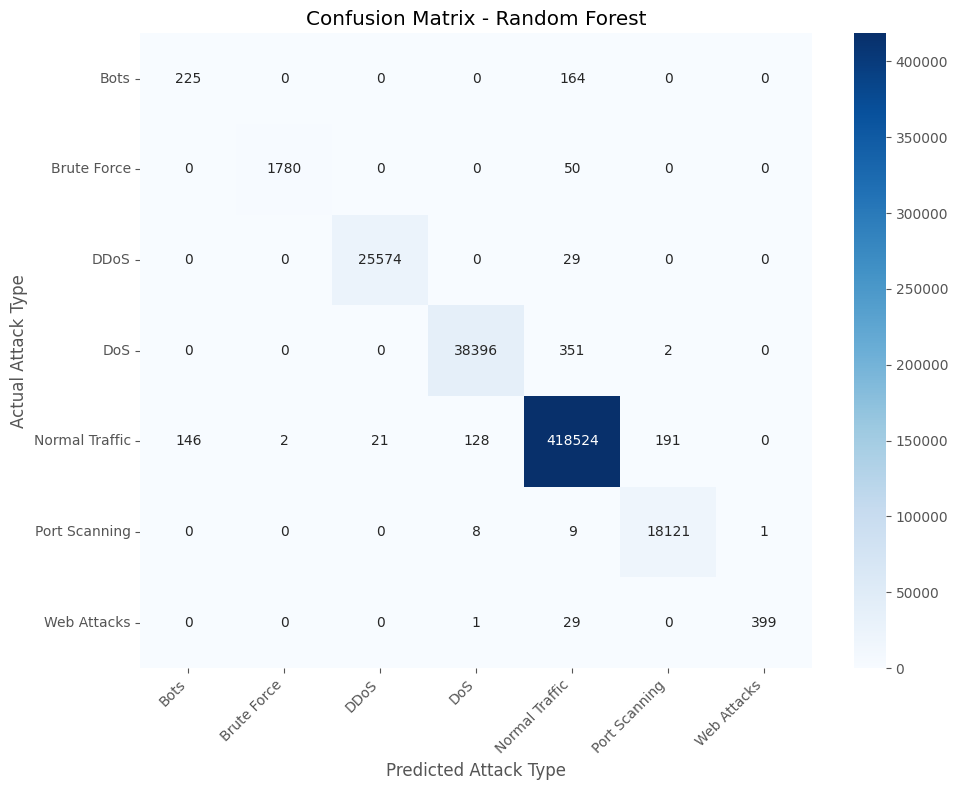

C:\Users\Tonny\AppData\Local\Temp\ipykernel_24964\1556690725.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


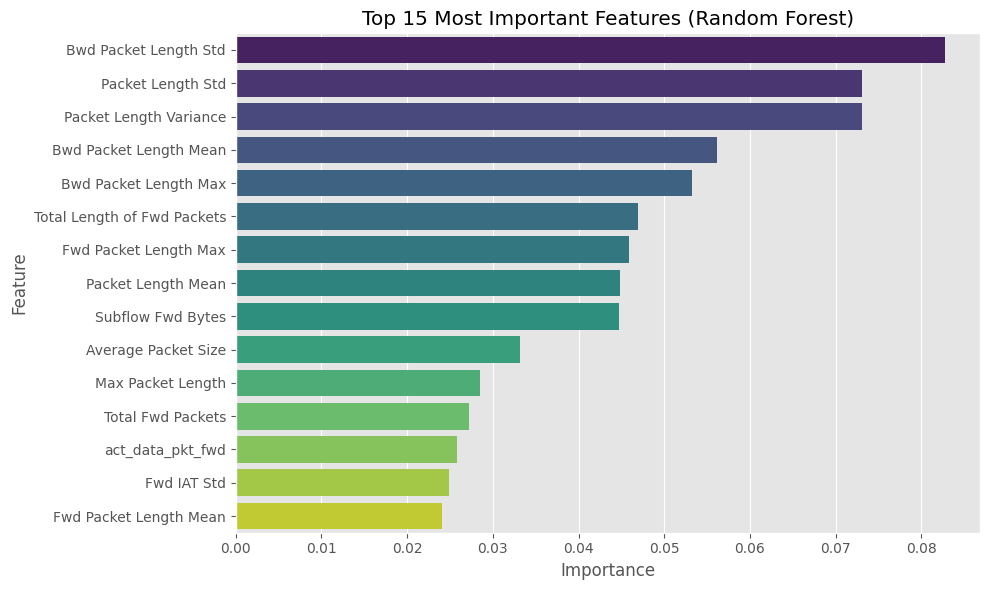

In [8]:
# 6. Evaluation
print("Predicting on the 20% Test Set...")
y_pred = clf.predict(X_test)

print("\n--- Classification Report ---")
# Use the encoder's classes to label the rows with actual attack names
target_names = [str(name) for name in le.classes_]
print(classification_report(y_test, y_pred, target_names=target_names))

# Plot a beautiful Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Attack Type')
plt.ylabel('Actual Attack Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot Feature Importance (Which features gave away the attacker the most?)
importances = clf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show() 
